# **Performed by Piyush Borhade**

**Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
%matplotlib inline
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

**Importing data**

In [3]:
data = pd.read_csv("Unemployment in India.csv");

In [4]:
data

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
data.shape

(768, 7)

**Check if their is any Null values present in the data!**

In [6]:
data.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [7]:
data.dropna(inplace=True)

In [8]:
data.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

**We have dropped the null values**

In [9]:
data.shape

(740, 7)

In [10]:
data.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [ ]:
data.describe().round()



,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.0,740.0,740.0
mean,12.0,7204460.0,43.0
std,11.0,8087988.0,8.0
min,0.0,49420.0,13.0
25%,5.0,1190404.0,38.0
50%,8.0,4744178.0,41.0
75%,16.0,11275490.0,46.0
max,77.0,45777509.0,73.0


In [24]:
data.columns = data.columns.str.strip()
print(data.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [25]:
numeric_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

corr = data[numeric_cols].corr()

print(corr)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 46.2+ KB


**We can observe that their are three columns with float datatype and four columns with object datatype!**

**Data Wrangling**

In [28]:
data.sample(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
56,Delhi,31-07-2019,Monthly,11.07,166605.0,40.53,Rural
638,Punjab,31-01-2020,Monthly,13.68,3252622.0,39.04,Urban
464,Goa,29-02-2020,Monthly,4.31,306396.0,39.73,Urban
553,Kerala,30-11-2019,Monthly,6.71,4062767.0,32.36,Urban
424,Chandigarh,29-02-2020,Monthly,16.67,316887.0,39.25,Urban
467,Gujarat,31-05-2019,Monthly,4.09,9686558.0,41.67,Urban
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
290,Telangana,31-05-2019,Monthly,2.23,11053353.0,61.74,Rural
692,Telangana,31-01-2020,Monthly,6.49,5543380.0,45.95,Urban
438,Chhattisgarh,30-04-2020,Monthly,20.13,1066126.0,24.06,Urban


**#Converting the date into datetime format**

In [30]:
data['Date']=pd.to_datetime(data['Date'])

In [31]:
data

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,2020-02-29,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban


**Extracting the year and month from the date**

In [32]:
year=[i.strftime('%Y') for i in list(data['Date'])]
month=[i.strftime('%B') for i in list(data['Date'])]

In [33]:
data['Year']=year
data['Month']=month

In [34]:
data

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,September
...,...,...,...,...,...,...,...,...,...
749,West Bengal,2020-02-29,Monthly,7.55,10871168.0,44.09,Urban,2020,February
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban,2020,March
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban,2020,April
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban,2020,May


**EDA**

In [35]:
data.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area',
       'Year', 'Month'],
      dtype='object')

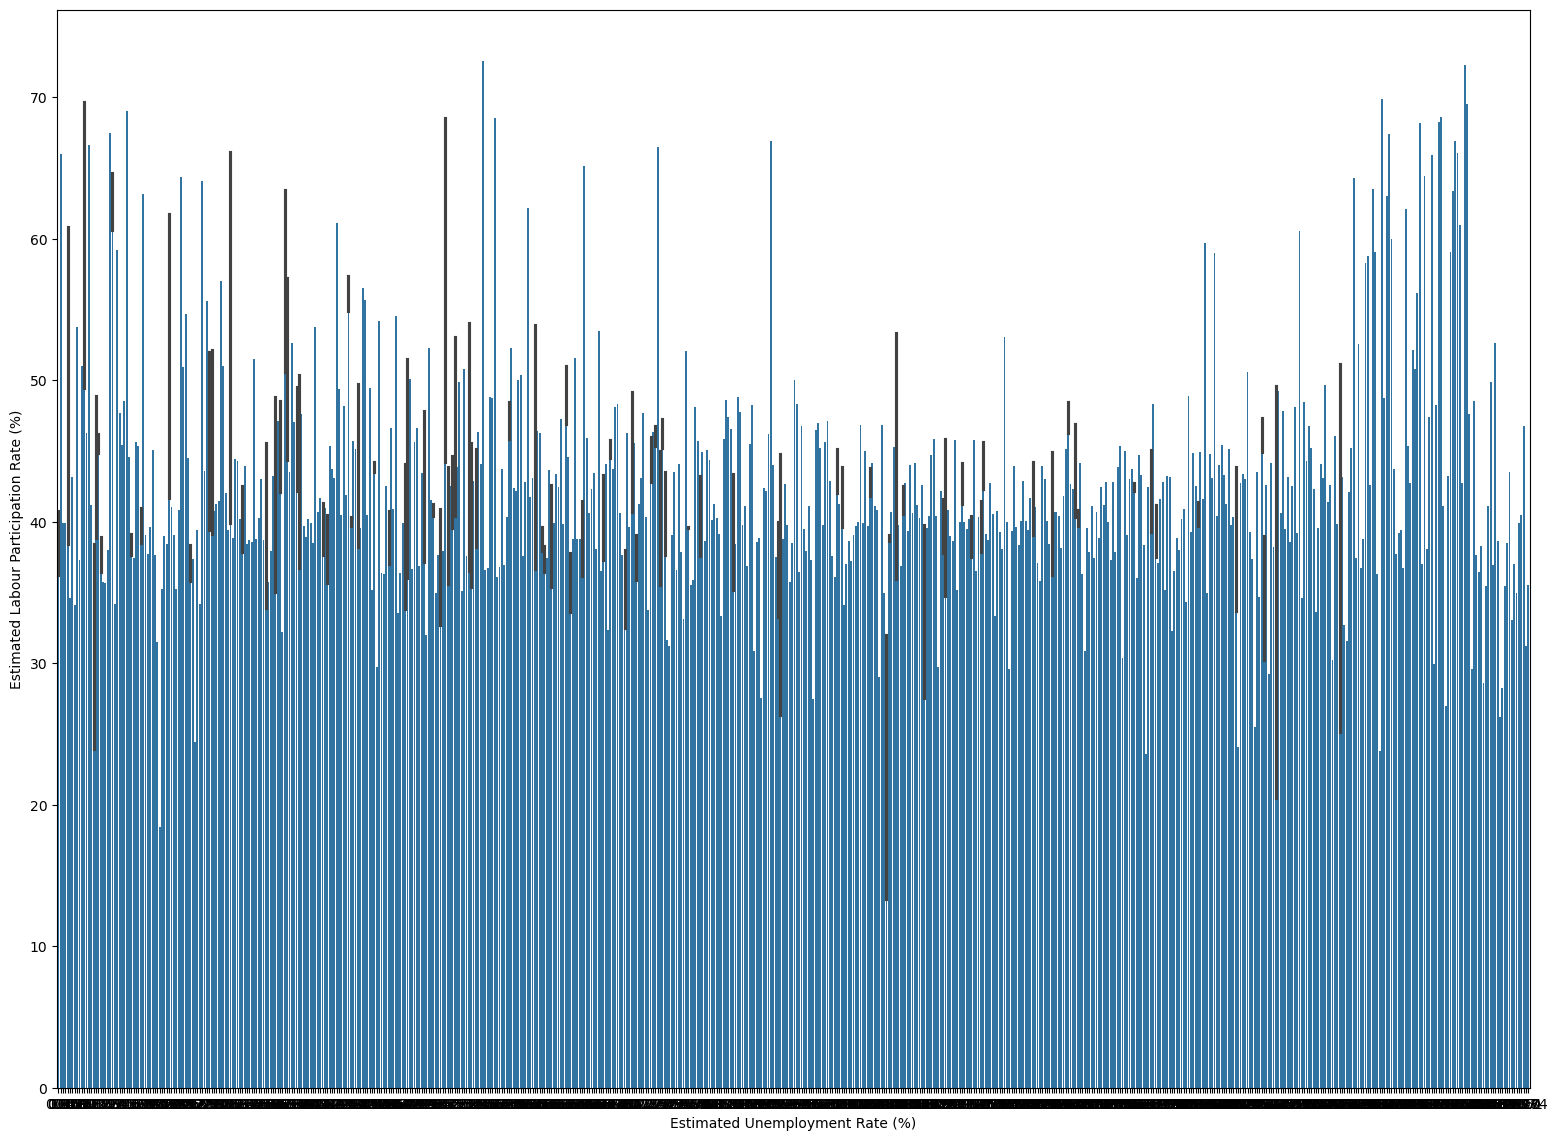

In [37]:
plt.figure(figsize=(19,14))
sns.barplot(x=data["Estimated Unemployment Rate (%)"], y=data["Estimated Labour Participation Rate (%)"]);

**Area wise unemployment analysis**

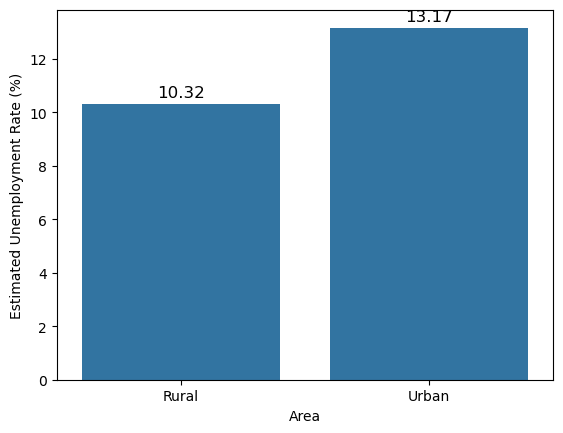

In [44]:
area_unemploy=data.groupby(['Area'],as_index=False)['Estimated Unemployment Rate (%)'].mean()
area_unemploy_plot=sns.barplot(data=area_unemploy,x='Area',y='Estimated Unemployment Rate (%)')
for bar in area_unemploy_plot.patches:
    area_unemploy_plot.annotate(format(bar.get_height(), '.2f'),
                   (bar.get_x() + bar.get_width() / 2,
                    bar.get_height()), ha='center', va='center',
                   size=12, xytext=(0, 8),
                   textcoords='offset points')

**We can conclude that Urban is having 13.17 of unemployment and Rural is having 10.32 of unemployment**

**Which state has the most data**

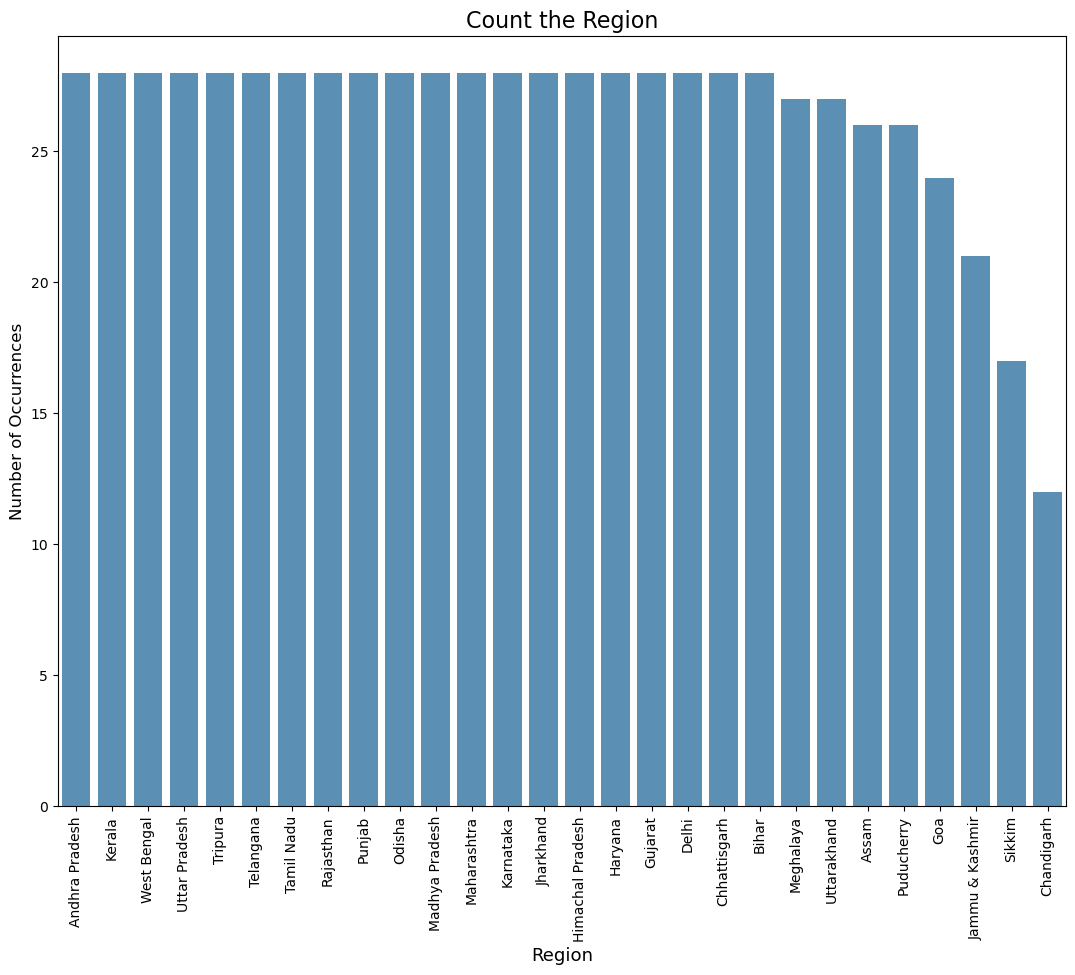

In [46]:
count1 = data.Region.value_counts()

plt.figure(figsize=(13,10))
#sns.barplot(count1.index, count1.values, alpha=0.8)
sns.barplot(x=count1.index, y=count1.values, alpha=0.8)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Region', fontsize=13)
plt.title('Count the Region', fontsize=16)
plt.xticks(rotation='vertical')
plt.show()

**Take the mean of rate state by state**

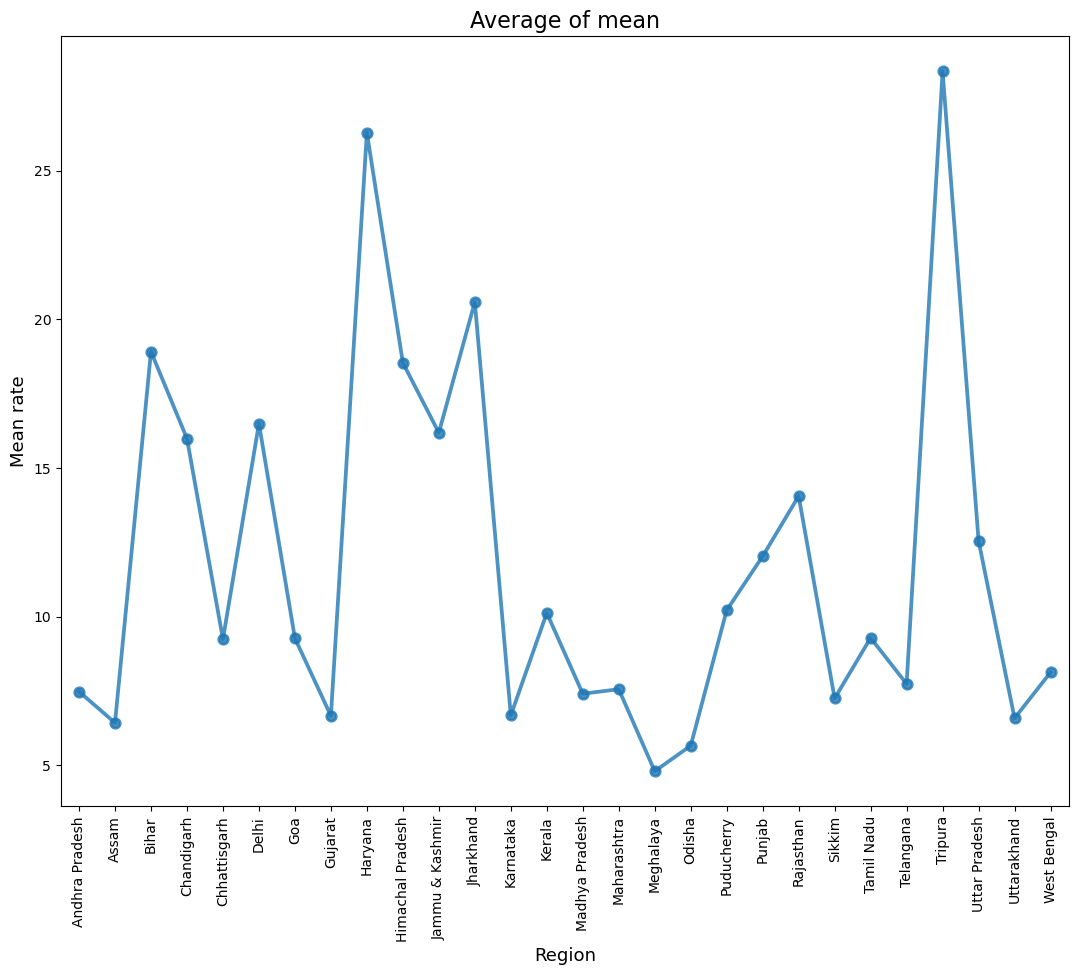

In [49]:
grouped = data.groupby(["Region"])["Estimated Unemployment Rate (%)"].aggregate("mean").reset_index()

plt.figure(figsize=(13,10))
sns.pointplot(x=grouped['Region'].values, y=grouped['Estimated Unemployment Rate (%)'].values, alpha=0.8)
plt.ylabel('Mean rate', fontsize=13)
plt.xlabel('Region', fontsize=13)
plt.title("Average of mean", fontsize=16)
plt.xticks(rotation='vertical')
plt.show()

In [50]:
unemploment = data[["Region", "Estimated Unemployment Rate (%)"]]
fig = px.sunburst(unemploment, path=["Region"], 
                     values="Estimated Unemployment Rate (%)", 
                     width=700, height=700, color_continuous_scale="RdY1Gn", 
                     title="Unemployment Rate in India")

fig.show()

**Unemployment rate is highest in Uttar Pradesh over 27% while lowest in Meghalayas at around 4% !**

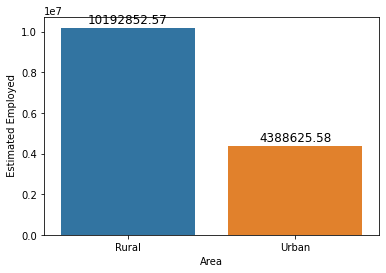

In [26]:
area_emp=data.groupby(['Area'],as_index=False)[' Estimated Employed'].mean()
area_emp_plot=sns.barplot(data=area_emp,x='Area',y=' Estimated Employed')
for bar in area_emp_plot.patches:
    area_emp_plot.annotate(format(bar.get_height(), '.2f'),
                   (bar.get_x() + bar.get_width() / 2,
                    bar.get_height()), ha='center', va='center',
                   size=12, xytext=(0, 8),
                   textcoords='offset points')

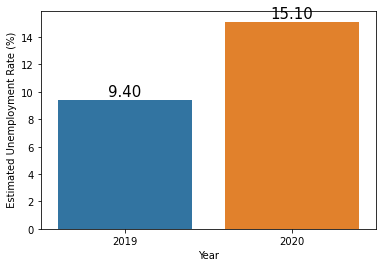

In [27]:
plot=sns.barplot(x='Year',y=' Estimated Unemployment Rate (%)',data=data.groupby('Year',as_index=False)[' Estimated Unemployment Rate (%)'].mean())

for bar in plot.patches:
 
  plot.annotate(format(bar.get_height(), '.2f'),
                   (bar.get_x() + bar.get_width() / 2,
                    bar.get_height()), ha='center', va='center',
                   size=15, xytext=(0, 8),
                   textcoords='offset points')

**As we can see that the rate from 2019 increased drastically from 9.40 to around 15.10 in just a year!**

## Conclusions: